In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Microsoft JhengHei'  # or 'Noto Sans TC'
plt.rcParams['axes.unicode_minus'] = False
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans, HDBSCAN
from sentence_transformers import SentenceTransformer
from umap import UMAP
from bertopic import BERTopic
import re, jieba, nltk, pickle, string
from nltk.corpus import stopwords

---

# 📰 News data

In [2]:
news = pd.read_csv('bbc-news-data.csv', sep='\t')
news

,category,filename,title,content
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...
...,...,...,...,...
2220,tech,397.txt,BT program to beat dialler scams,BT is introducing two initiatives to help bea...
2221,tech,398.txt,Spam e-mails tempt net shoppers,Computer users across the world continue to i...
2222,tech,399.txt,Be careful how you code,A new European directive could put software w...
2223,tech,400.txt,US cyber security chief resigns,The man making sure US computer networks are ...


In [3]:
news.isnull().sum()

category    0
filename    0
title       0
content     0
dtype: int64

In [4]:
news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  2225 non-null   object
 1   filename  2225 non-null   object
 2   title     2225 non-null   object
 3   content   2225 non-null   object
dtypes: object(4)
memory usage: 69.7+ KB


In [5]:
news.isna().sum()

category    0
filename    0
title       0
content     0
dtype: int64

In [6]:
news['title'].value_counts() == 2

title
Microsoft seeking spyware trojan       True
Troubled Marsh under SEC scrutiny      True
US peer-to-peer pirates convicted      True
Mobile multimedia slow to catch on     True
Edwards tips Idowu for Euro gold       True
                                      ...  
TV show unites Angolan families       False
Little Britain two top comic list     False
Brookside creator's Channel 4 bid     False
Muslim group attacks TV drama 24      False
Losing yourself in online gaming      False
Name: count, Length: 2096, dtype: bool

In [7]:
news[news.duplicated(subset='title', keep=False)]

,category,filename,title,content
6,business,007.txt,Jobs growth still slow in the US,The US created fewer jobs than expected in Ja...
213,business,214.txt,Economy 'strong' in election year,UK businesses are set to prosper during the n...
214,business,215.txt,SEC to rethink post-Enron rules,The US stock market watchdog's chairman has s...
239,business,240.txt,Economy 'strong' in election year,UK businesses are set to prosper during the n...
252,business,253.txt,Jobs growth still slow in the US,The US created fewer jobs than expected in Ja...
...,...,...,...,...
2211,tech,388.txt,Camera phones are 'must-haves',Four times more mobiles with cameras in them ...
2212,tech,389.txt,Mobile multimedia slow to catch on,There is no doubt that mobile phones sporting...
2214,tech,391.txt,Peer-to-peer nets 'here to stay',"Peer-to-peer (P2P) networks are here to stay,..."
2216,tech,393.txt,Savvy searchers fail to spot ads,Internet search engine users are an odd mix o...


In [8]:
news = news.drop_duplicates(subset='title', keep='first').reset_index(drop=True)

In [9]:
news['title'].duplicated().sum()

0

In [10]:
news['content'].value_counts() == 2

content
The owner of the technology-dominated Nasdaq stock index plans to sell shares to the public and list itself on the market it operates.  According to a registration document filed with the Securities and Exchange Commission, Nasdaq Stock Market plans to raise $100m (£52m) from the sale. Some observers see this as another step closer to a full public listing. However Nasdaq, an icon of the 1990s technology boom, recently poured cold water on those suggestions.  The company first sold shares in private placements during 2000 and 2001. It technically went public in 2002 when the stock started trading on the OTC Bulletin Board, which lists equities that trade only occasionally. Nasdaq will not make money from the sale, only investors who bought shares in the private placings, the filing documents said. The Nasdaq is made up shares in technology firms and other companies with high growth potential. It was the most potent symbol of the 1990s internet and telecoms boom, nose-diving aft

In [11]:
news[news.duplicated(subset='content', keep=False)]

,category,filename,title,content
264,business,267.txt,Nasdaq planning $100m share sale,The owner of the technology-dominated Nasdaq ...
283,business,286.txt,China continues breakneck growth,China's economy has expanded by a breakneck 9...
287,business,290.txt,Bank holds interest rate at 4.75%,The Bank of England has left interest rates o...
359,business,365.txt,Nasdaq planning $100m-share sale,The owner of the technology-dominated Nasdaq ...
430,business,438.txt,UK interest rates held at 4.75%,The Bank of England has left interest rates o...
...,...,...,...,...
2035,tech,290.txt,Fast moving phone viruses appear,Security firms are warning about several mobi...
2045,tech,321.txt,Consumer concern over RFID tags,Consumers are very concerned about the use of...
2047,tech,333.txt,US woman sues over ink cartridges,"A US woman is suing Hewlett Packard (HP), say..."
2080,tech,372.txt,Text message record smashed again,UK mobile owners continue to break records wi...


In [12]:
news = news.drop_duplicates(subset='content', keep='first').reset_index(drop=True)

In [13]:
news['content'].duplicated().sum()

0

In [14]:
news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2061 entries, 0 to 2060
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  2061 non-null   object
 1   filename  2061 non-null   object
 2   title     2061 non-null   object
 3   content   2061 non-null   object
dtypes: object(4)
memory usage: 64.5+ KB


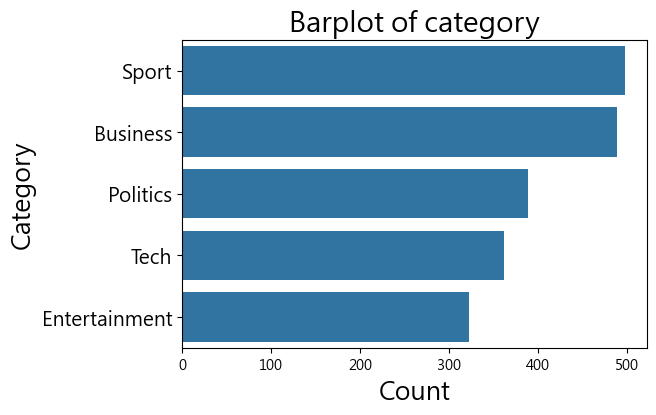

In [15]:
custom_labels=['Sport', 'Business', 'Politics', 'Tech', 'Entertainment']

plt.figure(figsize=(6, 4))
sns.countplot(data=news, y='category', order=news['category'].value_counts().index)
plt.title('Barplot of category', fontsize=20)
plt.xlabel('Count', fontsize=18)
plt.ylabel('Category', fontsize=18)
plt.yticks(ticks=range(len(custom_labels)) ,labels=custom_labels, fontsize=14)
plt.show()


In [16]:
def clean_text(text):
    """Lowercase, remove brackets/links/punctuation/numbers, collapse spaces."""
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))  # 刪標點
    text = re.sub(r'\[.*?\]', '', text)                               # 刪 [] 內內容
    text = re.sub(r'https?://\S+|www\.\S+', '', text)                 # 刪網址
    text = re.sub(r'<.*?>+', '', text)                                # 刪 HTML tag
    text = re.sub(r'\n', ' ', text)                                   # 換行→空白
    text = re.sub(r'\w*\d\w*', ' ', text)                             # 含數字詞
    text = re.sub(r'\d+', ' ', text)                                  # 數字
    text = re.sub(r'\s+', ' ', text).strip()                          # 連續空白
    return text

# 3️⃣ 套用到 DataFrame（新增一欄 cleaned_text）
news["cleaned_content"] = news["content"].apply(clean_text)
news.head()

,category,filename,title,content,cleaned_content
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...,quarterly profits at us media giant timewarner...
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...,the dollar has hit its highest level against t...
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...,the owners of embattled russian oil giant yuko...
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...,british airways has blamed high fuel prices fo...
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...,shares in uk drinks and food firm allied domec...


# ✅ Clear done

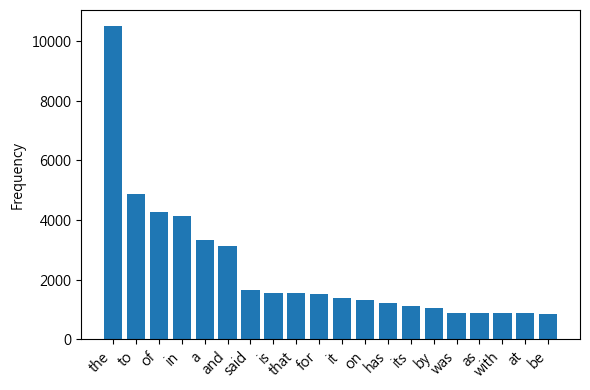

In [17]:
business = news[news["category"] == "business"]["cleaned_content"]

def tokenize(text):
    return [t for t in re.split(r'\s+', text) if t]

token_counter = Counter()
for doc in business:
    token_counter.update(tokenize(doc))

top_tokens = token_counter.most_common(20)
tokens, counts = zip(*top_tokens)

plt.figure(figsize=(6, 4))
plt.bar(tokens, counts)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


---
# 🖌 Install BERTopic

In [18]:
from bertopic import BERTopic
from bertopic.representation import MaximalMarginalRelevance    

---
# 📃 Business BERTopic

In [19]:
business_docs = business.to_list()

sentence_model = SentenceTransformer("all-mpnet-base-v2")
businessembeddings = sentence_model.encode(business_docs, show_progress_bar=True)

umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=15, metric='euclidean', cluster_selection_method='eom')
representation_model = MaximalMarginalRelevance(diversity=0.2)
vectorizer_model = CountVectorizer(stop_words='english')

business_topic_model = BERTopic(embedding_model=sentence_model,
                              vectorizer_model=vectorizer_model,
                              calculate_probabilities=True,
                              umap_model=umap_model,
                              hdbscan_model=hdbscan_model,
                              representation_model=representation_model,
                              verbose=True)

businessTopics, businessProbs = business_topic_model.fit_transform(business_docs, businessembeddings)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.4k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

2025-05-28 10:35:31,609 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-05-28 10:35:36,217 - BERTopic - Dimensionality - Completed ✓
2025-05-28 10:35:36,218 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-05-28 10:35:36,223 - BERTopic - Cluster - Completed ✓
2025-05-28 10:35:36,225 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-05-28 10:35:37,385 - BERTopic - Representation - Completed ✓


In [20]:
business_topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,132,-1_market_year_companies_china,"[market, year, companies, china, economic, inv...",[governments aid agencies insurers and travel ...
1,0,111,0_economy_economic_budget_deficit,"[economy, economic, budget, deficit, december,...",[us interest rates are to rise for the fourth ...
2,1,83,1_sales_company_fiat_gm,"[sales, company, fiat, gm, shares, business, b...",[general motors has warned that it expects ear...
3,2,65,2_ebbers_financial_fraud_company,"[ebbers, financial, fraud, company, firms, cha...",[former worldcom chief bernie ebbers has denie...
4,3,35,3_yukos_russian_gazprom_rosneft,"[yukos, russian, gazprom, rosneft, russia, kho...",[a littleknown russian company has bought the ...
5,4,29,4_airline_airlines_airbus_aircraft,"[airline, airlines, airbus, aircraft, boeing, ...",[budget airline ryanair has placed an order fo...
6,5,24,5_countries_imf_turkey_world,"[countries, imf, turkey, world, government, na...",[millions of the worlds poorest textile trade ...
7,6,19,6_deutsche_boerse_euronext_bid,"[deutsche, boerse, euronext, bid, exchange, ta...",[paneuropean stock market euronext has approac...


In [21]:
business_topic_model.get_topic_freq()

,Topic,Count
5,-1,132
1,0,111
0,1,83
6,2,65
2,3,35
3,4,29
4,5,24
7,6,19


---

# 🔎 Visualize Term

In [22]:
business_topic_model.visualize_barchart(top_n_topics=7, n_words=8)

---

# 🔎 Visualize Topics

In [23]:
business_topic_model.visualize_topics(use_ctfidf=True)

---

# 🔎 Visualize Topic Similarity

In [24]:
business_topic_model.visualize_heatmap(use_ctfidf=True)

---

# 🔎 Visualize Topics per Class

In [25]:
# topics_per_class = business_topic_model.topics_per_class(docs, classes=news["category"])
# business_topic_model.visualize_topics_per_class(topics_per_class)

# 🔎 Visualize documents with Plotly

In [26]:
business_topic_model.visualize_documents(business_docs, hide_annotations=True, 
                                         custom_labels=True, topics=list(range(30)),
                                         width=800, height=600)
# hide_annotations=True 隱藏每個clusters的名稱

# 🔎 Visualize documents with DataMapPlot

In [27]:
# import datamapplot
# topic_model.visualize_document_datamap(news['cleaned_content'])

# 🔎 Visualize Probabilities or Distribution¶

In [28]:
topic_distr, _ = business_topic_model.approximate_distribution(business_docs, min_similarity=0)
# business_topic_model.visualize_distribution(businessProbs[0])
business_topic_model.visualize_distribution(topic_distr[0])

100%|██████████| 1/1 [00:00<00:00,  1.38it/s]


In [29]:
similar_topics, similarity = business_topic_model.find_topics("economy", top_n=5)
business_topic_model.get_topic(similar_topics[0])

[('economy', 0.0365281978733829),
 ('economic', 0.03103072270957745),
 ('budget', 0.02124853096404044),
 ('deficit', 0.021077945912410145),
 ('december', 0.013922709902707666),
 ('economist', 0.013474698132271342),
 ('government', 0.013081194126172582),
 ('month', 0.01270207250004549),
 ('analysts', 0.012549256938086607),
 ('unemployment', 0.01241256284951095)]